In [5]:
# Week 3: Subqueries, CTEs, and Window Functions
### Dataset: Superstore Sales Data (9994 rows, 21 columns)

# **Objective:** Analyze sales data using SQL by applying Subqueries, CTEs, and Window Functions to solve business queries.

In [3]:
# ================================================
# Import Libraries
# ================================================
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import os

In [6]:
## Step 1: Load Dataset
# Loading Superstore CSV into Pandas DataFrame and inserting into MySQL.

In [7]:
# ================================================
# Reusable Helper Functions
# ================================================

def load_csv(filepath, encoding='latin1'):
    """Load CSV file into DataFrame"""
    df = pd.read_csv(filepath, encoding=encoding)
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

def connect_db(host, user, password, database):
    """Create MySQL database connection"""
    conn = mysql.connector.connect(
        host=host,
        user=user,
        password=password,
        database=database
    )
    print(f"Connected to database: {database}")
    return conn

def insert_data(conn, df):
    """Insert DataFrame rows into superstore_raw table"""
    cursor = conn.cursor()
    count = 0
    for _, row in df.iterrows():
        cursor.execute("""
            INSERT IGNORE INTO superstore_raw VALUES 
            (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
        """, tuple(row))
        count += 1
    conn.commit()
    cursor.close()
    print(f"Inserted {count} rows successfully!")

def get_top_customers(df, n=5):
    """Return top N customers by total sales"""
    return df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(n)

def get_category_sales(df):
    """Return total sales grouped by category"""
    return df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

def get_above_avg_customers(df):
    """Return customers with above average total sales"""
    customer_sales = df.groupby('Customer Name')['Sales'].sum()
    avg = customer_sales.mean()
    return customer_sales[customer_sales > avg].sort_values(ascending=False)

def get_monthly_trend(df):
    """Return monthly sales trend"""
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    return df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

In [9]:
# ================================================
# Load Data and Insert into MySQL
# ================================================
df = load_csv('Sample - Superstore.csv')
conn = connect_db('127.0.0.1', 'root', 'MaaBaglamukhi@8', 'superstore')
insert_data(conn, df)
conn.close()

Dataset loaded: 9994 rows, 21 columns
Connected to database: superstore
Inserted 9994 rows successfully!


In [10]:
## Step 2: Data Analysis & Visualizations
# Using reusable functions to analyze customer sales patterns.

=== Top 5 Customers ===
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

=== Sales by Category ===
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

=== Above Average Customers ===
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
                   ...    
Julie Kriz        2932.484
Shaun Weien       2921.544
Maris LaWare      2921.500
Rob Dowd          2912.894
Craig Yedwab      2900.026
Name: Sales, Length: 294, dtype: float64


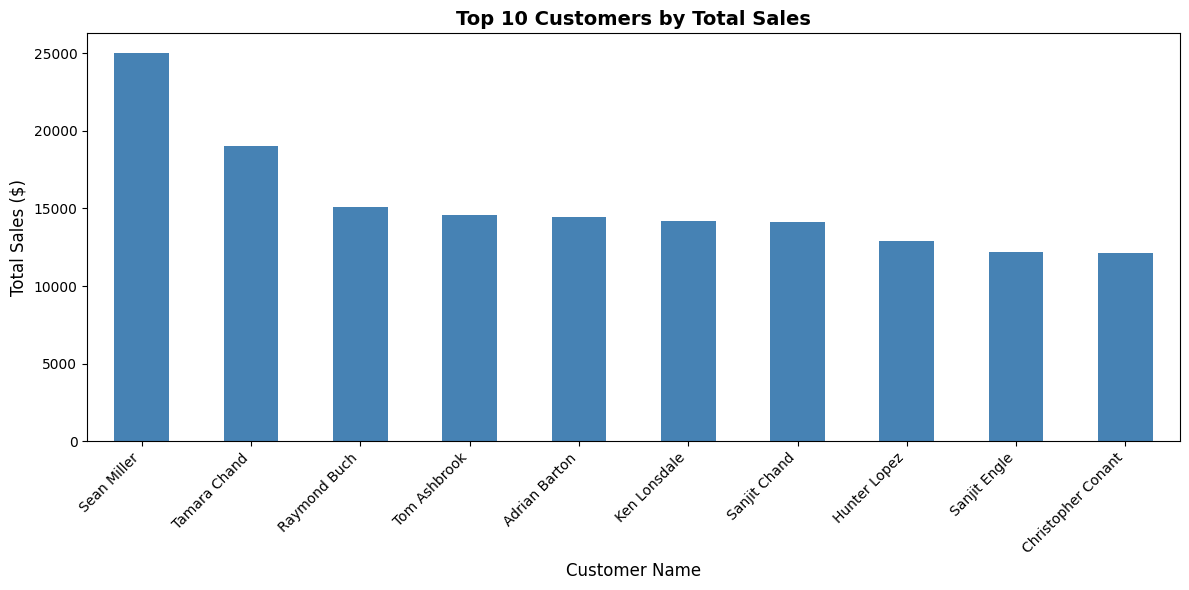

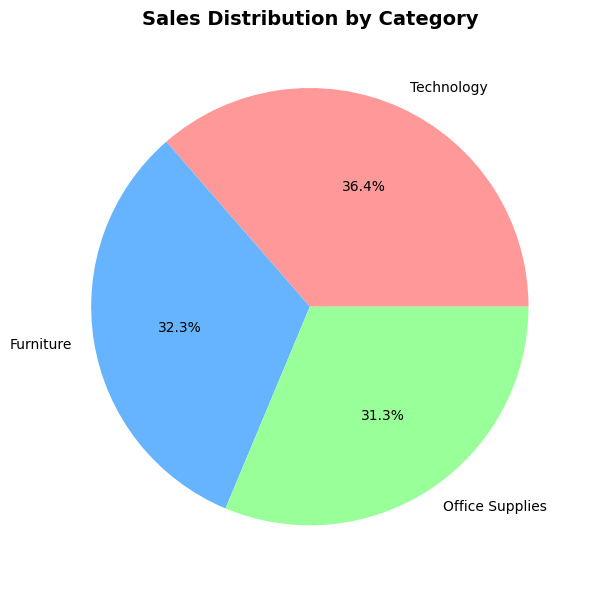

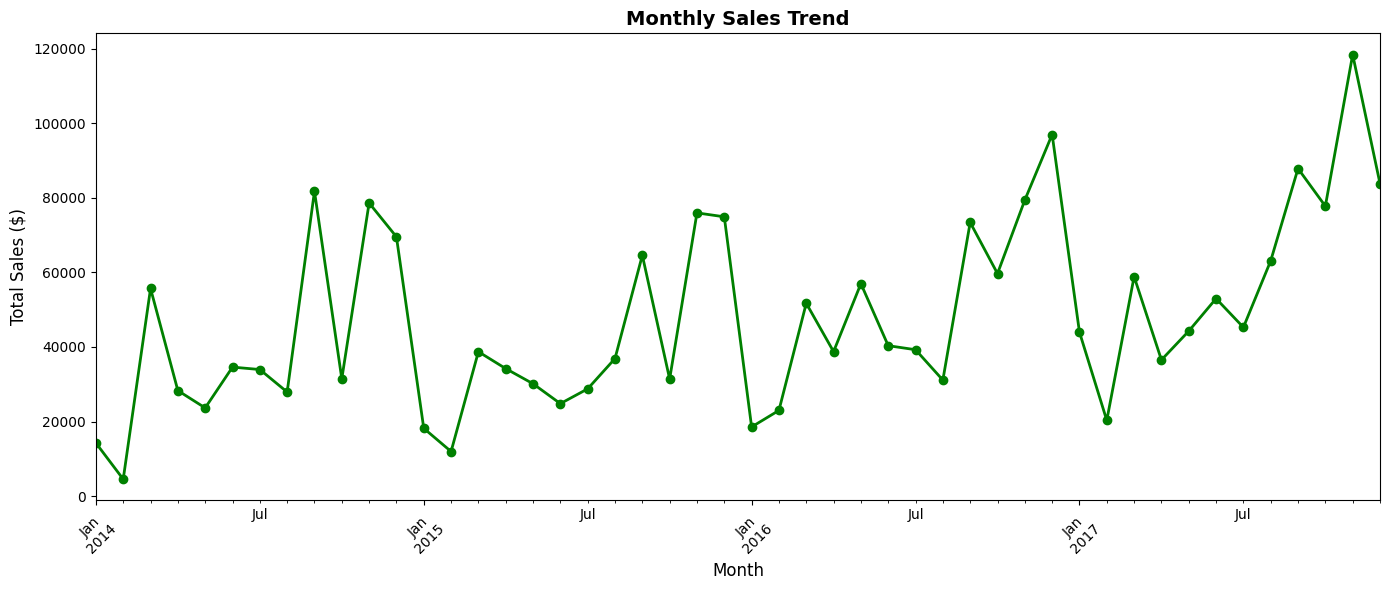

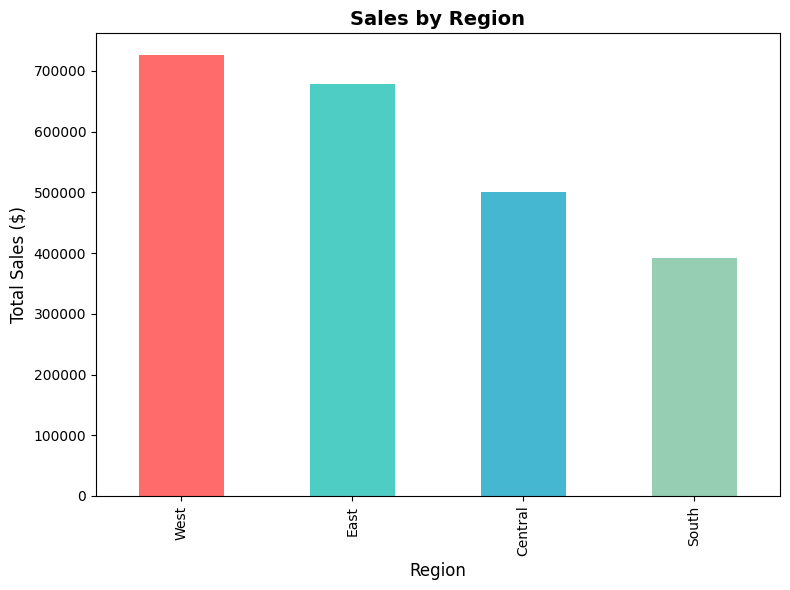

In [11]:
# ================================================
# Analysis using Reusable Functions
# ================================================

# Top 5 customers
print("=== Top 5 Customers ===")
print(get_top_customers(df, 5))

# Category sales
print("\n=== Sales by Category ===")
print(get_category_sales(df))

# Above average customers
print("\n=== Above Average Customers ===")
print(get_above_avg_customers(df))

# ================================================
# Visualization 1: Top 10 Customers
# ================================================
top_customers = get_top_customers(df, 10)
plt.figure(figsize=(12, 6))
top_customers.plot(kind='bar', color='steelblue')
plt.title('Top 10 Customers by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Customer Name', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_customers.png', dpi=150)
plt.show()

# ================================================
# Visualization 2: Sales by Category
# ================================================
category_sales = get_category_sales(df)
plt.figure(figsize=(8, 6))
category_sales.plot(kind='pie', autopct='%1.1f%%', 
                   colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Sales Distribution by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_sales.png', dpi=150)
plt.show()

# ================================================
# Visualization 3: Monthly Sales Trend
# ================================================
monthly = get_monthly_trend(df)
plt.figure(figsize=(14, 6))
monthly.plot(kind='line', color='green', marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

# ================================================
# Visualization 4: Regional Sales
# ================================================
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
region_sales.plot(kind='bar', color=['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4'])
plt.title('Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('regional_sales.png', dpi=150)
plt.show()

In [ ]:
## Summary
- Dataset: 9994 rows, 21 columns loaded successfully
- Top Customer: Sean Miller with highest total sales
- Best Category: Technology leads in revenue
- Peak Sales: Q4 (October-December) shows highest sales
- Regional Leader: West region dominates sales